In [25]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

BASE_DIR = Path(".").resolve()

import sys
sys.path.insert(0, str(BASE_DIR.parent.parent / "modelling/shared"))
from hb_shared_utils import compute_wca, build_regressors

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

INPUT_DIR_PANEL = BASE_DIR.parent.parent
INPUT_DIR_CFO_FORECASTS = BASE_DIR.parent.parent / "data/processed_data_lseg"
raw = pd.read_csv(INPUT_DIR_CFO_FORECASTS / "cfo_forecasts_monthly_nok.csv")
raw = raw.assign(snapshot_date=pd.to_datetime(raw["snapshot_date"]))

START_YEAR = 2013

raw = raw[raw["snapshot_date"].dt.year >= START_YEAR].copy()

print(f"Raw rows:        {len(raw):,}")
print(f"Unique tickers:  {raw['Ticker'].nunique()}")
print(f"Date range:      {raw['snapshot_date'].min().date()} to {raw['snapshot_date'].max().date()}")

# Dedup same-day duplicates (FY rolling artifacts) — keep last value per (Ticker, date)
n_before = len(raw)
raw = raw.sort_values(["Ticker", "snapshot_date"])
raw = (
    raw.groupby(["Ticker", "snapshot_date"], as_index=False)["cfo_forecast"]
       .mean()
)
print(f"After dedup:          {len(raw):,}  ({n_before - len(raw)} same-day duplicates removed)")

print("\nForecast value percentiles:")
print(raw["cfo_forecast"].describe(percentiles=[0.001, 0.01, 0.99, 0.999]).round(2))

Raw rows:        33,417
Unique tickers:  572
Date range:      2013-07-19 to 2025-12-31
After dedup:          32,989  (428 same-day duplicates removed)

Forecast value percentiles:
count     32989.00
mean       5548.96
std       17944.26
min      -14475.89
0.1%      -2452.86
1%         -451.49
50%        1002.70
99%       69293.29
99.9%    231595.97
max      413156.87
Name: cfo_forecast, dtype: float64


In [26]:
raw = raw.assign(
    Year=raw["snapshot_date"].dt.year,
    Month=raw["snapshot_date"].dt.month,
)

# Method A: Mean per calendar year (smoothest, your supervisor's suggestion)
annual_mean = (
    raw.groupby(["Ticker", "Year"])["cfo_forecast"]
    .mean().reset_index()
    .rename(columns={"cfo_forecast": "cfo_forecast_mean", "Year": "FiscalYear"})
)

# Method B: Median per year (robust to monthly outliers)
annual_median = (
    raw.groupby(["Ticker", "Year"])["cfo_forecast"]
    .median().reset_index()
    .rename(columns={"cfo_forecast": "cfo_forecast_median", "Year": "FiscalYear"})
)

# Method C: Last observation per year (most informed; closest to year-end)
annual_last = (
    raw.sort_values(["Ticker", "Year", "snapshot_date"])
    .groupby(["Ticker", "Year"], as_index=False)
    .last()[["Ticker", "Year", "cfo_forecast"]]
    .rename(columns={"cfo_forecast": "cfo_forecast_last", "Year": "FiscalYear"})
)

# Method D: Specific month (e.g., June)
annual_jun = raw.loc[raw["Month"].isin([3, 4, 5, 6]), ["Ticker", "Year", "cfo_forecast"]].copy()
annual_jun = annual_jun.rename(columns={"cfo_forecast": "cfo_forecast_jun", "Year": "FiscalYear"})
annual_jun = annual_jun.drop_duplicates(subset=["Ticker", "FiscalYear"], keep="last")

# Merge all methods into one frame
annual = (annual_mean
    .merge(annual_median, on=["Ticker", "FiscalYear"], how="outer")
    .merge(annual_last,   on=["Ticker", "FiscalYear"], how="outer")
    .merge(annual_jun,    on=["Ticker", "FiscalYear"], how="outer"))

# Quick check — how correlated are the four methods?
print(annual[["cfo_forecast_mean","cfo_forecast_median","cfo_forecast_last","cfo_forecast_jun"]].corr().round(3))

                     cfo_forecast_mean  cfo_forecast_median  \
cfo_forecast_mean                1.000                0.999   
cfo_forecast_median              0.999                1.000   
cfo_forecast_last                0.992                0.994   
cfo_forecast_jun                 0.997                0.997   

                     cfo_forecast_last  cfo_forecast_jun  
cfo_forecast_mean                0.992             0.997  
cfo_forecast_median              0.994             0.997  
cfo_forecast_last                1.000             0.989  
cfo_forecast_jun                 0.989             1.000  


In [27]:
panel = pd.read_csv(INPUT_DIR_PANEL / "results/extraction_static/prepared_step2_input.csv")
panel = compute_wca(panel)
panel = build_regressors(panel, include_lead=True)

panel["avg_assets"] = (panel["AT"] + panel.groupby("Ticker")["AT"].shift(1)) / 2

# Restrict to analysis window AFTER lags/leads have been constructed.
panel = panel[panel["Year"] >= START_YEAR].copy()

# Merge analyst forecast onto panel.
forecast = annual.copy()
forecast["Year"] = forecast["FiscalYear"] - 1   # row Year=Y has forecast for Y+1

panel = panel.merge(
    forecast[["Ticker", "Year", "cfo_forecast_jun"]],
    on=["Ticker", "Year"], how="left",
)

panel["cfo_forecast_scaled"] = panel["cfo_forecast_jun"] / panel["avg_assets"]

# Compare analyst forecast (scaled) to realized CFO_{t+1} (scaled)
val = panel.dropna(subset=["cfo_forecast_scaled", "CFO_lead1_scaled"]).copy()

print(f"Validation sample: {len(val)} firm-years with both forecast and realized")
print(f"Years covered: {val['Year'].min()}–{val['Year'].max()}")
print(f"Unique firms: {val['Ticker'].nunique()}")

val["error"] = val["cfo_forecast_scaled"] - val["CFO_lead1_scaled"]
val["abs_error"] = val["error"].abs()
val["pct_error"] = val["error"] / val["CFO_lead1_scaled"].abs()

print("\nForecast accuracy (scaled CFO):")
print(f"  RMSE:               {np.sqrt((val['error']**2).mean()):.4f}")
print(f"  MAE:                {val['abs_error'].mean():.4f}")
print(f"  Median |error|:     {val['abs_error'].median():.4f}")
print(f"  Mean error (bias):  {val['error'].mean():+.4f}")
print(f"  Pearson r:          {pearsonr(val['cfo_forecast_scaled'], val['CFO_lead1_scaled'])[0]:.3f}")
print(f"  Spearman ρ:         {spearmanr(val['cfo_forecast_scaled'], val['CFO_lead1_scaled'])[0]:.3f}")

Validation sample: 3784 firm-years with both forecast and realized
Years covered: 2013–2023
Unique firms: 539

Forecast accuracy (scaled CFO):
  RMSE:               0.5992
  MAE:                0.0654
  Median |error|:     0.0277
  Mean error (bias):  +0.0219
  Pearson r:          0.329
  Spearman ρ:         0.769


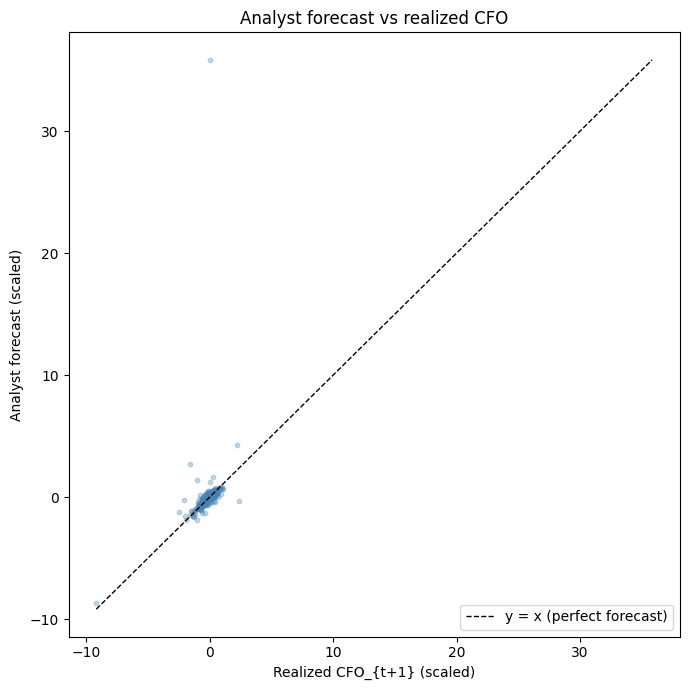

In [28]:
# Visual check: scatter of forecast vs realized
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(val["CFO_lead1_scaled"], val["cfo_forecast_scaled"], 
           alpha=0.3, s=10, color="steelblue")
lims = [val[["CFO_lead1_scaled","cfo_forecast_scaled"]].min().min(),
        val[["CFO_lead1_scaled","cfo_forecast_scaled"]].max().max()]
ax.plot(lims, lims, "k--", lw=1, label="y = x (perfect forecast)")
ax.set_xlabel("Realized CFO_{t+1} (scaled)")
ax.set_ylabel("Analyst forecast (scaled)")
ax.set_title("Analyst forecast vs realized CFO")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# ═══ Coverage diagnostic: how many forecast years are missing per firm? ═══

# We're interested in coverage *within each firm's panel of realized CFO*.
# That tells us: of the firm-years for which DD-style accrual modelling is 
# meaningful, how many have an analyst forecast available?

# Take only firm-years where we have a realized CFO_lead1 (else AR(1)/analyst
# comparison isn't meaningful for that row anyway)
realized = panel.dropna(subset=["CFO_lead1_scaled"]).copy()

def coverage_per_firm(group):
    n_realized = len(group)
    n_with_forecast = group["cfo_forecast_scaled"].notna().sum()
    n_missing = n_realized - n_with_forecast
    first_year = int(group["Year"].min())
    last_year = int(group["Year"].max())
    
    # Years where we have realized but no forecast
    missing_years = sorted(group.loc[group["cfo_forecast_scaled"].isna(), "Year"]
                           .astype(int).tolist())
    
    return pd.Series({
        "n_realized_years":  n_realized,
        "n_with_forecast":   int(n_with_forecast),
        "n_missing":         int(n_missing),
        "coverage_pct":      n_with_forecast / n_realized * 100 if n_realized > 0 else np.nan,
        "first_realized":    first_year,
        "last_realized":     last_year,
        "missing_years":     missing_years,
    })

coverage = (
    realized.groupby("Ticker")
    .apply(coverage_per_firm, include_groups=False)
    .reset_index()
)

print(f"Firms in panel with realized CFO: {len(coverage)}")
print(f"\nDistribution of forecast coverage (% of realized firm-years with a forecast):")
print(coverage["coverage_pct"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))

print("\nDistribution of missing forecast years per firm:")
print(coverage["n_missing"].describe().round(1))

print(f"\nFirms with 100% forecast coverage:    {(coverage['coverage_pct'] == 100).sum()}")
print(f"Firms with 0% forecast coverage:      {(coverage['coverage_pct'] == 0).sum()}")
print(f"Firms with partial coverage:          {((coverage['coverage_pct'] > 0) & (coverage['coverage_pct'] < 100)).sum()}")

Firms in panel with realized CFO: 633

Distribution of forecast coverage (% of realized firm-years with a forecast):
count    633.0
mean      62.1
std       36.5
min        0.0
10%        0.0
25%       33.3
50%       72.7
75%      100.0
90%      100.0
max      100.0
Name: coverage_pct, dtype: float64

Distribution of missing forecast years per firm:
count    633.0
mean       3.5
std        3.7
min        0.0
25%        0.0
50%        2.0
75%        6.0
max       11.0
Name: n_missing, dtype: float64

Firms with 100% forecast coverage:    192
Firms with 0% forecast coverage:      94
Firms with partial coverage:          347


In [30]:
zero_cov_tickers = coverage.loc[coverage["coverage_pct"] == 0, "Ticker"].tolist()

n_panel_before    = len(panel)
n_firms_before    = panel["Ticker"].nunique()
n_realized_before = len(realized)

panel    = panel[~panel["Ticker"].isin(zero_cov_tickers)].copy()
realized = realized[~realized["Ticker"].isin(zero_cov_tickers)].copy()
coverage = coverage[coverage["coverage_pct"] > 0].reset_index(drop=True)
val      = val[~val["Ticker"].isin(zero_cov_tickers)].copy()

print(f"Dropped zero-coverage firms: {len(zero_cov_tickers)}")
print(f"  Panel firms:    {n_firms_before:,} → {panel['Ticker'].nunique():,}")
print(f"  Panel rows:     {n_panel_before:,} → {len(panel):,}")
print(f"  Realized rows:  {n_realized_before:,} → {len(realized):,}")
print(f"  Validation rows:{len(val):,}")

Dropped zero-coverage firms: 94
  Panel firms:    633 → 539
  Panel rows:     6,816 → 5,858
  Realized rows:  5,987 → 5,150
  Validation rows:3,784


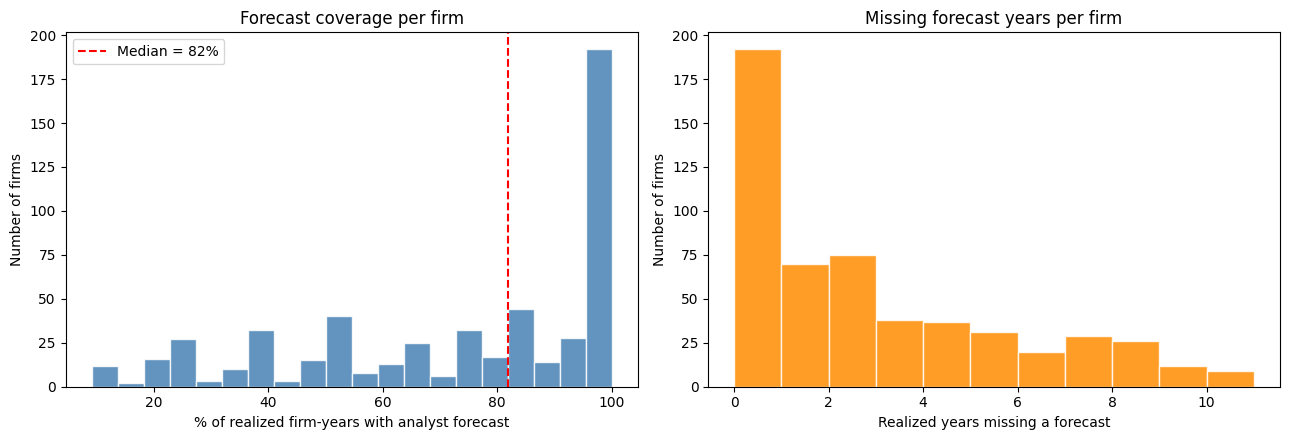

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(coverage["coverage_pct"], bins=20, color="steelblue", 
             edgecolor="white", alpha=0.85)
axes[0].axvline(coverage["coverage_pct"].median(), color="red", ls="--",
                label=f"Median = {coverage['coverage_pct'].median():.0f}%")
axes[0].set_xlabel("% of realized firm-years with analyst forecast")
axes[0].set_ylabel("Number of firms")
axes[0].set_title("Forecast coverage per firm")
axes[0].legend()

axes[1].hist(coverage["n_missing"], bins=range(0, int(coverage["n_missing"].max()) + 2),
             color="darkorange", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Realized years missing a forecast")
axes[1].set_ylabel("Number of firms")
axes[1].set_title("Missing forecast years per firm")

plt.tight_layout()
plt.show()

In [32]:
EXCHANGE_LABELS = {".OL": "Oslo", ".ST": "Stockholm", ".CO": "Copenhagen",
                   ".HE": "Helsinki", ".IC": "Iceland"}

def parse_exchange(ticker: str) -> str:
    for sfx, label in EXCHANGE_LABELS.items():
        if ticker.endswith(sfx):
            return label
    return "Other"

coverage["exchange"] = coverage["Ticker"].map(parse_exchange)

by_exch = (
    coverage.groupby("exchange")
    .agg(
        n_firms=("Ticker", "count"),
        n_zero_coverage=("coverage_pct", lambda s: int((s == 0).sum())),
        n_full_coverage=("coverage_pct", lambda s: int((s == 100).sum())),
        median_coverage_pct=("coverage_pct", "median"),
        median_missing_yrs=("n_missing", "median"),
    )
)
by_exch["pct_with_any"] = (
    (by_exch["n_firms"] - by_exch["n_zero_coverage"]) / by_exch["n_firms"] * 100
).round(1)

by_exch = by_exch[["n_firms", "pct_with_any", "n_zero_coverage",
                   "n_full_coverage", "median_coverage_pct", "median_missing_yrs"]]
print("Forecast coverage by exchange:")
print(by_exch)

Forecast coverage by exchange:
            n_firms  pct_with_any  n_zero_coverage  n_full_coverage  \
exchange                                                              
Copenhagen       56         100.0                0               28   
Helsinki        105         100.0                0               57   
Iceland           5         100.0                0                1   
Oslo            132         100.0                0               30   
Stockholm       241         100.0                0               76   

            median_coverage_pct  median_missing_yrs  
exchange                                             
Copenhagen            95.454545                 0.5  
Helsinki             100.000000                 0.0  
Iceland               50.000000                 2.0  
Oslo                  72.727273                 2.0  
Stockholm             77.777778                 2.0  


In [33]:
# ═══ Which firms have zero forecast coverage? ═══

# Average AT across each firm's realized panel — used as a size proxy
mean_at = realized.groupby("Ticker")["AT"].mean()
coverage["mean_AT"] = coverage["Ticker"].map(mean_at)

zero_cov = coverage[coverage["coverage_pct"] == 0].copy()

print(f"Zero-coverage firms: {len(zero_cov)} / {len(coverage)}")
print("\nBreakdown by exchange:")
print(zero_cov.groupby("exchange").size().sort_values(ascending=False))

print("\nSize comparison (mean of mean_AT, in reporting units):")
print(f"  Zero-coverage firms:   {zero_cov['mean_AT'].mean():>12,.0f}")
print(f"  Any-coverage firms:    {coverage.loc[coverage['coverage_pct'] > 0, 'mean_AT'].mean():>12,.0f}")
print(f"  Full-coverage firms:   {coverage.loc[coverage['coverage_pct'] == 100, 'mean_AT'].mean():>12,.0f}")

# Save the zero-coverage list for an audit pass
zero_cov[["Ticker", "exchange", "n_realized_years", "first_realized",
          "last_realized", "mean_AT"]].to_csv(
    BASE_DIR / "zero_coverage_firms.csv", index=False
)
print(f"\nSaved zero-coverage firm list to: {BASE_DIR / 'zero_coverage_firms.csv'}")

Zero-coverage firms: 0 / 539

Breakdown by exchange:
Series([], dtype: int64)

Size comparison (mean of mean_AT, in reporting units):
  Zero-coverage firms:            nan
  Any-coverage firms:          25,527
  Full-coverage firms:         54,371

Saved zero-coverage firm list to: /Users/sondregrontvedt/Documents/Industriell Økonomi og Teknologiledelse/excel_extract_project/modelling/analysis/zero_coverage_firms.csv


In [34]:
# ═══ Coverage by size decile ═══
# Expectation: monotonic — bigger firms have more analyst attention.
# Strong monotonicity here is the expected pattern, NOT a bug.

cov_sized = coverage.dropna(subset=["mean_AT"]).copy()
cov_sized["size_decile"] = pd.qcut(cov_sized["mean_AT"], q=10, labels=False) + 1

by_size = cov_sized.groupby("size_decile").agg(
    n_firms=("Ticker", "count"),
    pct_with_any=("coverage_pct", lambda s: (s > 0).mean() * 100),
    median_coverage_pct=("coverage_pct", "median"),
    median_AT=("mean_AT", "median"),
).round(1)

print("Coverage by size decile (1 = smallest, 10 = largest):")
print(by_size)

Coverage by size decile (1 = smallest, 10 = largest):
             n_firms  pct_with_any  median_coverage_pct  median_AT
size_decile                                                       
1                 54         100.0                 36.4      240.1
2                 54         100.0                 54.5      498.6
3                 54         100.0                 62.5      929.0
4                 54         100.0                 75.0     1588.8
5                 54         100.0                 81.8     2942.6
6                 53         100.0                 72.7     5204.7
7                 54         100.0                 88.9     8536.2
8                 54         100.0                 90.9    16821.0
9                 54         100.0                100.0    32351.8
10                54         100.0                100.0   121569.3


In [35]:
# ═══ Year-by-year coverage trend ═══

yearly_cov = (
    realized.assign(has_forecast=realized["cfo_forecast_scaled"].notna())
    .groupby("Year")
    .agg(
        n_firm_years=("Ticker", "count"),
        n_with_forecast=("has_forecast", "sum"),
    )
)
yearly_cov["pct_covered"] = (
    yearly_cov["n_with_forecast"] / yearly_cov["n_firm_years"] * 100
).round(1)
print("Year-by-year forecast coverage:")
print(yearly_cov)

Year-by-year forecast coverage:
      n_firm_years  n_with_forecast  pct_covered
Year                                            
2013           368              226         61.4
2014           379              245         64.6
2015           413              269         65.1
2016           440              309         70.2
2017           460              341         74.1
2018           475              348         73.3
2019           496              364         73.4
2020           513              376         73.3
2021           531              414         78.0
2022           538              441         82.0
2023           537              451         84.0


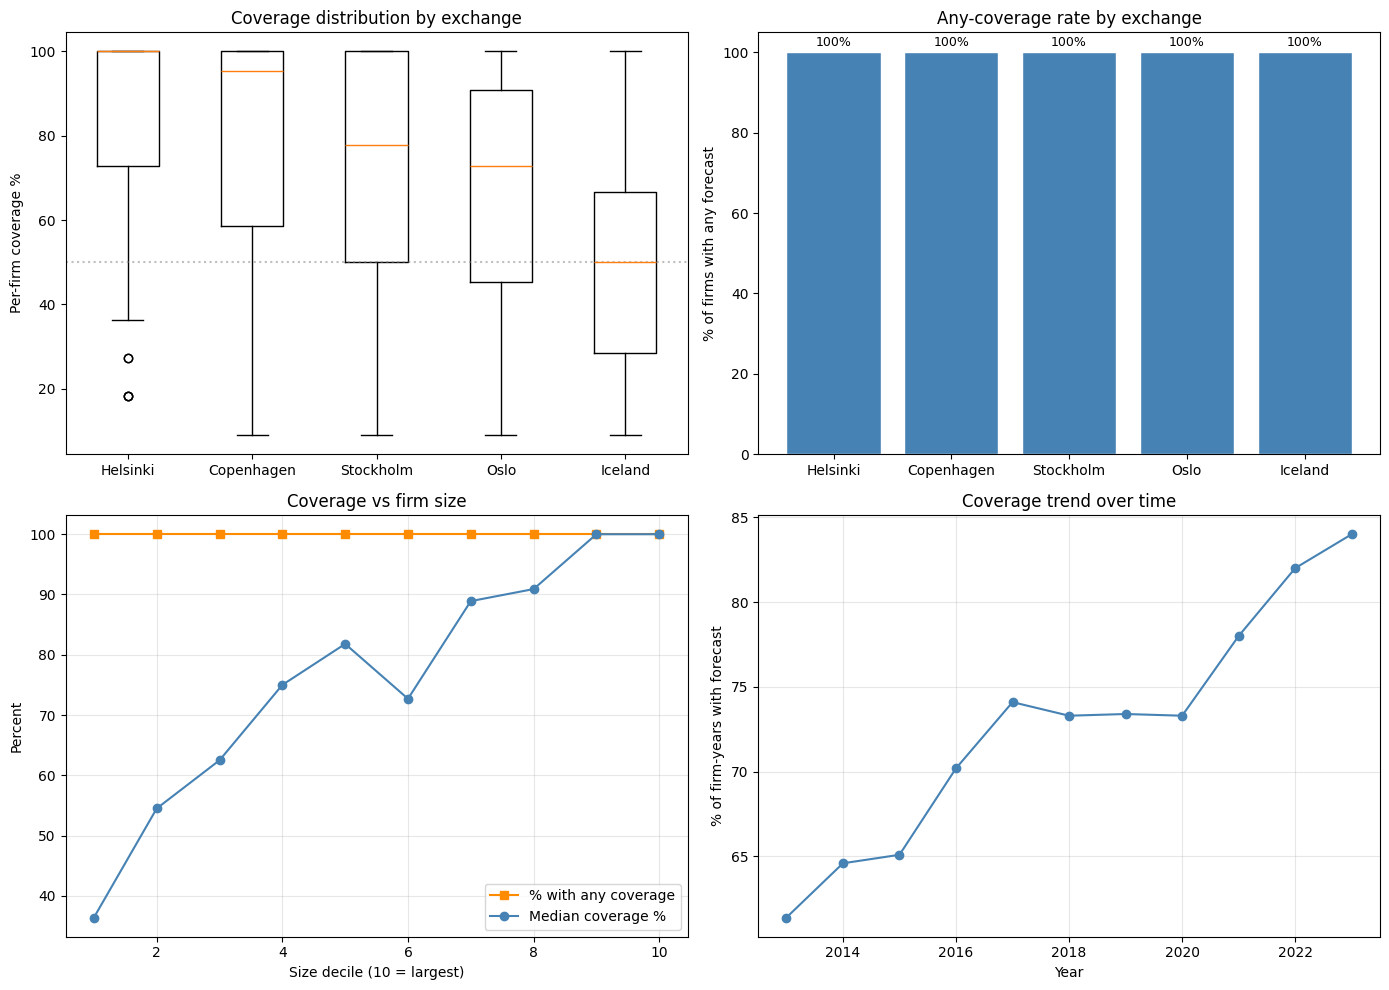

In [36]:
# ═══ Visual summary ═══

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Coverage % distribution by exchange (boxplot)
exch_order = (coverage.groupby("exchange")["coverage_pct"].median()
              .sort_values(ascending=False).index.tolist())
data = [coverage.loc[coverage["exchange"] == e, "coverage_pct"] for e in exch_order]
axes[0, 0].boxplot(data, tick_labels=exch_order)
axes[0, 0].set_ylabel("Per-firm coverage %")
axes[0, 0].set_title("Coverage distribution by exchange")
axes[0, 0].axhline(50, color="gray", ls=":", alpha=0.5)

# (2) Any-coverage rate by exchange (bar)
pct_any = (coverage.assign(any_cov=coverage["coverage_pct"] > 0)
           .groupby("exchange")["any_cov"].mean() * 100).reindex(exch_order)
axes[0, 1].bar(pct_any.index, pct_any.values, color="steelblue", edgecolor="white")
axes[0, 1].set_ylabel("% of firms with any forecast")
axes[0, 1].set_title("Any-coverage rate by exchange")
for x, y in zip(pct_any.index, pct_any.values):
    axes[0, 1].text(x, y + 1.5, f"{y:.0f}%", ha="center", fontsize=9)
axes[0, 1].set_ylim(0, 105)

# (3) Coverage vs size decile
axes[1, 0].plot(by_size.index, by_size["pct_with_any"], "s-",
                color="darkorange", label="% with any coverage")
axes[1, 0].plot(by_size.index, by_size["median_coverage_pct"], "o-",
                color="steelblue", label="Median coverage %")
axes[1, 0].set_xlabel("Size decile (10 = largest)")
axes[1, 0].set_ylabel("Percent")
axes[1, 0].set_title("Coverage vs firm size")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# (4) Coverage trend over time
axes[1, 1].plot(yearly_cov.index, yearly_cov["pct_covered"], "o-",
                color="steelblue")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("% of firm-years with forecast")
axes[1, 1].set_title("Coverage trend over time")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()